In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle

class Vocabulary:
    """
    Builds a word-to-index mapping from a corpus.

    Special tokens:
        <PAD> = 0  → used to pad sequences to equal length in a batch
        <SOS> = 1  → Start Of Sequence, fed as first token to the decoder
        <EOS> = 2  → End Of Sequence, signals the decoder to stop generating
        <UNK> = 3  → Unknown token, replaces any word not in vocabulary
    """

    PAD_TOKEN = "<PAD>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    UNK_TOKEN = "<UNK>"

    PAD_IDX = 0
    SOS_IDX = 1
    EOS_IDX = 2
    UNK_IDX = 3

    def __init__(self, min_freq: int = 2):
        """
        Args:
            min_freq: words appearing fewer than this many times
                      across the whole corpus are mapped to <UNK>.
                      Keeps vocabulary size manageable.
        """
        self.min_freq = min_freq

        # These are set after calling .build()
        self.word2idx = {}
        self.idx2word = {}
        self.word_freq = Counter()
        self.vocab_size = 0

    # ── tokenizer ──────────────────────────────────────────
    @staticmethod
    def tokenize(text: str) -> list[str]:
        """
        Simple whitespace tokenizer.
        The data is already cleaned so no need for anything fancier.
        Returns a list of lowercase tokens.
        """
        if not isinstance(text, str):
            return []
        return text.lower().strip().split()

    # ── count word frequencies ─────────────────────────────
    def fit(self, sentences: list[str]):
        """
        Count every word in the corpus.
        Call this on BOTH source (body) and target (title) sentences
        so both sides share the same vocabulary.
        (Shared vocab is standard for seq2seq on similar domains.)
        """
        for sentence in sentences:
            tokens = self.tokenize(sentence)
            self.word_freq.update(tokens)
        return self  # allows chaining: vocab.fit(x).fit(y)

    # ── build index mappings ───────────────────────────────
    def build(self):
        """
        After calling .fit(), call .build() to create the
        word2idx and idx2word dictionaries.
        Words below min_freq are dropped (they'll map to <UNK>).
        """
        # Start with special tokens at fixed indices
        self.word2idx = {
            self.PAD_TOKEN: self.PAD_IDX,
            self.SOS_TOKEN: self.SOS_IDX,
            self.EOS_TOKEN: self.EOS_IDX,
            self.UNK_TOKEN: self.UNK_IDX,
        }

        # Add words that meet the frequency threshold
        for word, freq in self.word_freq.most_common():
            if freq >= self.min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)

        # Reverse mapping: index → word (for decoding predictions)
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)

        print(f"Vocabulary built ✓")
        print(f"  Total unique words seen : {len(self.word_freq):,}")
        print(f"  Words kept (freq ≥ {self.min_freq})  : {self.vocab_size:,}")
        print(f"  Words dropped as <UNK>  : {len(self.word_freq) - (self.vocab_size - 4):,}")
        return self

    # ── convert text ↔ indices ─────────────────────────────
    def encode(self, sentence: str, add_sos: bool = False, add_eos: bool = True) -> list[int]:
        """
        Convert a sentence string into a list of integer indices.

        Args:
            sentence : raw text string
            add_sos  : prepend <SOS> token (used for decoder input)
            add_eos  : append <EOS> token (used for target sequences)

        Returns:
            List of integer token indices.
        """
        tokens = self.tokenize(sentence)
        indices = [self.word2idx.get(t, self.UNK_IDX) for t in tokens]

        if add_sos:
            indices = [self.SOS_IDX] + indices
        if add_eos:
            indices = indices + [self.EOS_IDX]

        return indices

    def decode(self, indices: list[int], skip_special: bool = True) -> str:
        """
        Convert a list of integer indices back into a human-readable string.

        Args:
            indices      : list of token indices (model output)
            skip_special : if True, drops <PAD>, <SOS>, <EOS> from output
        """
        special = {self.PAD_IDX, self.SOS_IDX, self.EOS_IDX}
        words = []
        for idx in indices:
            if skip_special and idx in special:
                continue
            word = self.idx2word.get(idx, self.UNK_TOKEN)
            words.append(word)
            if word == self.EOS_TOKEN and not skip_special:
                break  # stop at end token
        return " ".join(words)

    # ── save / load ────────────────────────────────────────
    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self, f)
        print(f"Vocabulary saved → {path}")

    @classmethod
    def load(cls, path: str) -> "Vocabulary":
        with open(path, "rb") as f:
            vocab = pickle.load(f)
        print(f"Vocabulary loaded ← {path} ({vocab.vocab_size:,} words)")
        return vocab

vocab = Vocabulary.load("vocabulary.pkl")

# Confirm PyTorch is available
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")

Vocabulary loaded ← vocabulary.pkl (33,379 words)
PyTorch version : 2.10.0+cpu
CUDA available  : False
Using device    : cpu


In [9]:
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

print(f"Vocabulary size : {vocab.vocab_size:,}")
print(f"Train rows      : {len(train_df):,}")
print(f"Val rows        : {len(val_df):,}")
print(f"Test rows       : {len(test_df):,}")

Vocabulary size : 33,379
Train rows      : 28,830
Val rows        : 3,204
Test rows       : 3,560


In [11]:
MAX_SRC_LEN = 81   # encoder input length  (body)
MAX_TGT_LEN = 12   # decoder target length (title + SOS + EOS)
BATCH_SIZE  = 64   # number of samples per batch

print(f"MAX_SRC_LEN : {MAX_SRC_LEN}")
print(f"MAX_TGT_LEN : {MAX_TGT_LEN}")
print(f"BATCH_SIZE  : {BATCH_SIZE}")

MAX_SRC_LEN : 81
MAX_TGT_LEN : 12
BATCH_SIZE  : 64


In [13]:
class ReviewSummarizationDataset(Dataset):
    """
    Converts raw CSV rows into padded integer tensors.

    For each sample it returns:
        src     : encoder input  — body encoded + padded to MAX_SRC_LEN
        tgt     : decoder target — title with SOS prepended + EOS appended,
                                   padded to MAX_TGT_LEN
        src_len : actual (non-padded) length of src — needed by the encoder
                  to use pack_padded_sequence efficiently
        tgt_len : actual (non-padded) length of tgt — needed by the loss
                  function to ignore PAD positions

    Why we store lengths:
        Padding is necessary for batching but we don't want the model to
        "learn" anything from PAD tokens. Storing the true lengths lets us
        mask them out in the loss calculation later.
    """

    def __init__(self, df: pd.DataFrame, vocab: Vocabulary,
                 max_src_len: int, max_tgt_len: int):
        """
        Args:
            df          : DataFrame with columns body_final, title_final
            vocab       : built Vocabulary object from Step 1
            max_src_len : maximum encoder input length
            max_tgt_len : maximum decoder target length (including SOS + EOS)
        """
        self.vocab       = vocab
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

        # Drop rows with null text just in case
        df = df.dropna(subset=["body_final", "title_final"]).reset_index(drop=True)

        self.bodies = df["body_final"].tolist()
        self.titles = df["title_final"].tolist()

        print(f"Dataset created with {len(self.bodies):,} samples")

    def __len__(self):
        return len(self.bodies)

    def __getitem__(self, idx):
        """
        Returns one (src, tgt, src_len, tgt_len) tuple for a given index.

        src encoding  : body_final → encode (no SOS, with EOS) → pad/truncate
        tgt encoding  : title_final → encode (with SOS, with EOS) → pad/truncate

        Why EOS on src?  It signals to the encoder where the input ends.
        Why SOS on tgt?  The decoder needs a starting token before it
                         generates the first real output word.
        """
        body  = str(self.bodies[idx])
        title = str(self.titles[idx])

        # ── Source (body) ──────────────────────────────────────
        src_ids = self.vocab.encode(body,  add_sos=False, add_eos=True)

        # Record true length BEFORE padding (capped at max_src_len)
        src_len = min(len(src_ids), self.max_src_len)

        # Truncate if too long
        src_ids = src_ids[:self.max_src_len]

        # Pad with PAD_IDX if too short
        src_ids = src_ids + [self.vocab.PAD_IDX] * (self.max_src_len - len(src_ids))

        # ── Target (title) ─────────────────────────────────────
        tgt_ids = self.vocab.encode(title, add_sos=True,  add_eos=True)

        # Record true length BEFORE padding (capped at max_tgt_len)
        tgt_len = min(len(tgt_ids), self.max_tgt_len)

        # Truncate if too long
        tgt_ids = tgt_ids[:self.max_tgt_len]

        # Pad with PAD_IDX if too short
        tgt_ids = tgt_ids + [self.vocab.PAD_IDX] * (self.max_tgt_len - len(tgt_ids))

        return (
            torch.tensor(src_ids, dtype=torch.long),  # shape: (MAX_SRC_LEN,)
            torch.tensor(tgt_ids, dtype=torch.long),  # shape: (MAX_TGT_LEN,)
            torch.tensor(src_len, dtype=torch.long),  # scalar
            torch.tensor(tgt_len, dtype=torch.long),  # scalar
        )


In [15]:
def collate_fn(batch):
    """
    Custom collate function for the DataLoader.

    Default PyTorch collate stacks tensors — that works fine here since
    all sequences are already padded to fixed lengths. However we also
    sort the batch by descending src_len. This is required by PyTorch's
    pack_padded_sequence (used in the Encoder in Step 3) which expects
    sequences sorted longest-first.

    Args:
        batch : list of (src, tgt, src_len, tgt_len) tuples

    Returns:
        src      : (BATCH_SIZE, MAX_SRC_LEN)
        tgt      : (BATCH_SIZE, MAX_TGT_LEN)
        src_lens : (BATCH_SIZE,) sorted descending
        tgt_lens : (BATCH_SIZE,)
    """
    srcs, tgts, src_lens, tgt_lens = zip(*batch)

    srcs     = torch.stack(srcs)      # (B, MAX_SRC_LEN)
    tgts     = torch.stack(tgts)      # (B, MAX_TGT_LEN)
    src_lens = torch.stack(src_lens)  # (B,)
    tgt_lens = torch.stack(tgt_lens)  # (B,)

    # Sort by src_len descending (required for pack_padded_sequence)
    src_lens, sort_idx = src_lens.sort(descending=True)
    srcs     = srcs[sort_idx]
    tgts     = tgts[sort_idx]
    tgt_lens = tgt_lens[sort_idx]

    return srcs, tgts, src_lens, tgt_lens


# ── Cell 2-F: Build Datasets & DataLoaders ────────────────────
train_dataset = ReviewSummarizationDataset(train_df, vocab, MAX_SRC_LEN, MAX_TGT_LEN)
val_dataset   = ReviewSummarizationDataset(val_df,   vocab, MAX_SRC_LEN, MAX_TGT_LEN)
test_dataset  = ReviewSummarizationDataset(test_df,  vocab, MAX_SRC_LEN, MAX_TGT_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,        # Shuffle ONLY for training
    collate_fn  = collate_fn,
    num_workers = 0,           # Set to 2-4 if on a multi-core machine
    pin_memory  = torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,       # Never shuffle val/test
    collate_fn  = collate_fn,
    num_workers = 0,
    pin_memory  = torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    collate_fn  = collate_fn,
    num_workers = 0,
    pin_memory  = torch.cuda.is_available()
)

print(f"\nTrain batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")
print(f"\nEach batch shape:")
print(f"  src      : ({BATCH_SIZE}, {MAX_SRC_LEN})")
print(f"  tgt      : ({BATCH_SIZE}, {MAX_TGT_LEN})")
print(f"  src_lens : ({BATCH_SIZE},)")
print(f"  tgt_lens : ({BATCH_SIZE},)")

Dataset created with 28,830 samples
Dataset created with 3,204 samples
Dataset created with 3,560 samples

Train batches : 451
Val batches   : 51
Test batches  : 56

Each batch shape:
  src      : (64, 81)
  tgt      : (64, 12)
  src_lens : (64,)
  tgt_lens : (64,)


In [17]:
src_batch, tgt_batch, src_lens, tgt_lens = next(iter(train_loader))

print("── One Batch Sanity Check ──────────────────────────────")
print(f"src_batch shape : {src_batch.shape}")
print(f"tgt_batch shape : {tgt_batch.shape}")
print(f"src_lens shape  : {src_lens.shape}")
print(f"tgt_lens shape  : {tgt_lens.shape}")
print()

# Decode the first sample in the batch back to text
sample_src = src_batch[0].tolist()
sample_tgt = tgt_batch[0].tolist()

print(f"── Sample 0 (first in batch) ───────────────────────────")
print(f"Raw src indices (first 15) : {sample_src[:15]}")
print(f"Raw tgt indices            : {sample_tgt}")
print()
print(f"Decoded src : {vocab.decode(sample_src, skip_special=True)}")
print(f"Decoded tgt : {vocab.decode(sample_tgt, skip_special=True)}")
print()
print(f"True src length : {src_lens[0].item()} tokens (rest are PAD)")
print(f"True tgt length : {tgt_lens[0].item()} tokens (rest are PAD)")
print()

# Verify PAD tokens are at the correct positions
pad_positions_src = [i for i, x in enumerate(sample_src) if x == vocab.PAD_IDX]
pad_positions_tgt = [i for i, x in enumerate(sample_tgt) if x == vocab.PAD_IDX]
true_src_len = src_lens[0].item()
true_tgt_len = tgt_lens[0].item()

src_pad_ok = all(i >= true_src_len for i in pad_positions_src)
tgt_pad_ok = all(i >= true_tgt_len for i in pad_positions_tgt)

print(f"PAD tokens start at index {true_src_len} in src : {'✓' if src_pad_ok else '✗'}")
print(f"PAD tokens start at index {true_tgt_len} in tgt : {'✓' if tgt_pad_ok else '✗'}")

# Verify SOS is first token in tgt and EOS appears before PAD
sos_ok = sample_tgt[0] == vocab.SOS_IDX
print(f"tgt[0] is <SOS>            : {'✓' if sos_ok else '✗'}")

eos_positions = [i for i, x in enumerate(sample_tgt) if x == vocab.EOS_IDX]
eos_ok = len(eos_positions) > 0 and eos_positions[0] < true_tgt_len
print(f"<EOS> appears before PADs  : {'✓' if eos_ok else '✗'}")

print(f"\n✅  Step 2 basic checks passed — ready for visualizations")

── One Batch Sanity Check ──────────────────────────────
src_batch shape : torch.Size([64, 81])
tgt_batch shape : torch.Size([64, 12])
src_lens shape  : torch.Size([64])
tgt_lens shape  : torch.Size([64])

── Sample 0 (first in batch) ───────────────────────────
Raw src indices (first 15) : [40, 947, 344, 159, 5275, 39, 4493, 6515, 8544, 24, 3443, 6515, 26542, 1254, 16369]
Raw tgt indices            : [1, 13, 720, 183, 132, 1868, 597, 2, 0, 0, 0, 0]

Decoded src : got kit today tried clone old 250 gb hdd new 500 gb firt followed 123 procedure ran app windows vista new hdd destination enclosure copy hdd laptop finishing cloning 120 min clone <UNK> swapped <UNK> showed boot manager <UNK> reversed hdd copying booted apricom cd source usb drive destination new hdd laptop time <UNK> feature turned error message booting step totally waisted 3 <UNK> thing acronis <UNK> home 2011 come <UNK> acronis cd booted laptop cloned hdd 100 minutes new drive
Decoded tgt : a solid case but lousy software


In [19]:
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ddd",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#2a2a2a",
    "grid.linewidth":   0.8,
})
ACCENT = ["#4fc3f7", "#81c784", "#ffb74d", "#e57373", "#ce93d8"]
print("Visualization setup done ✓")

Visualization setup done ✓


In [21]:
print("── V2-1: Pulling 3 batches and checking shapes ─────────")

shape_errors = []
for i, (src, tgt, sl, tl) in enumerate(train_loader):
    if src.shape  != (BATCH_SIZE, MAX_SRC_LEN): shape_errors.append(f"Batch {i}: src shape {src.shape}")
    if tgt.shape  != (BATCH_SIZE, MAX_TGT_LEN): shape_errors.append(f"Batch {i}: tgt shape {tgt.shape}")
    if sl.shape   != (BATCH_SIZE,):             shape_errors.append(f"Batch {i}: src_lens shape {sl.shape}")
    if tl.shape   != (BATCH_SIZE,):             shape_errors.append(f"Batch {i}: tgt_lens shape {tl.shape}")
    if i == 2:
        break

if shape_errors:
    print("ERRORS FOUND:")
    for e in shape_errors: print(f"  ✗ {e}")
else:
    print(f"  ✓ src shape      : ({BATCH_SIZE}, {MAX_SRC_LEN})  — correct")
    print(f"  ✓ tgt shape      : ({BATCH_SIZE}, {MAX_TGT_LEN})  — correct")
    print(f"  ✓ src_lens shape : ({BATCH_SIZE},)  — correct")
    print(f"  ✓ tgt_lens shape : ({BATCH_SIZE},)  — correct")
    print(f"  ✓ All 3 batches passed shape checks")

── V2-1: Pulling 3 batches and checking shapes ─────────
  ✓ src shape      : (64, 81)  — correct
  ✓ tgt shape      : (64, 12)  — correct
  ✓ src_lens shape : (64,)  — correct
  ✓ tgt_lens shape : (64,)  — correct
  ✓ All 3 batches passed shape checks


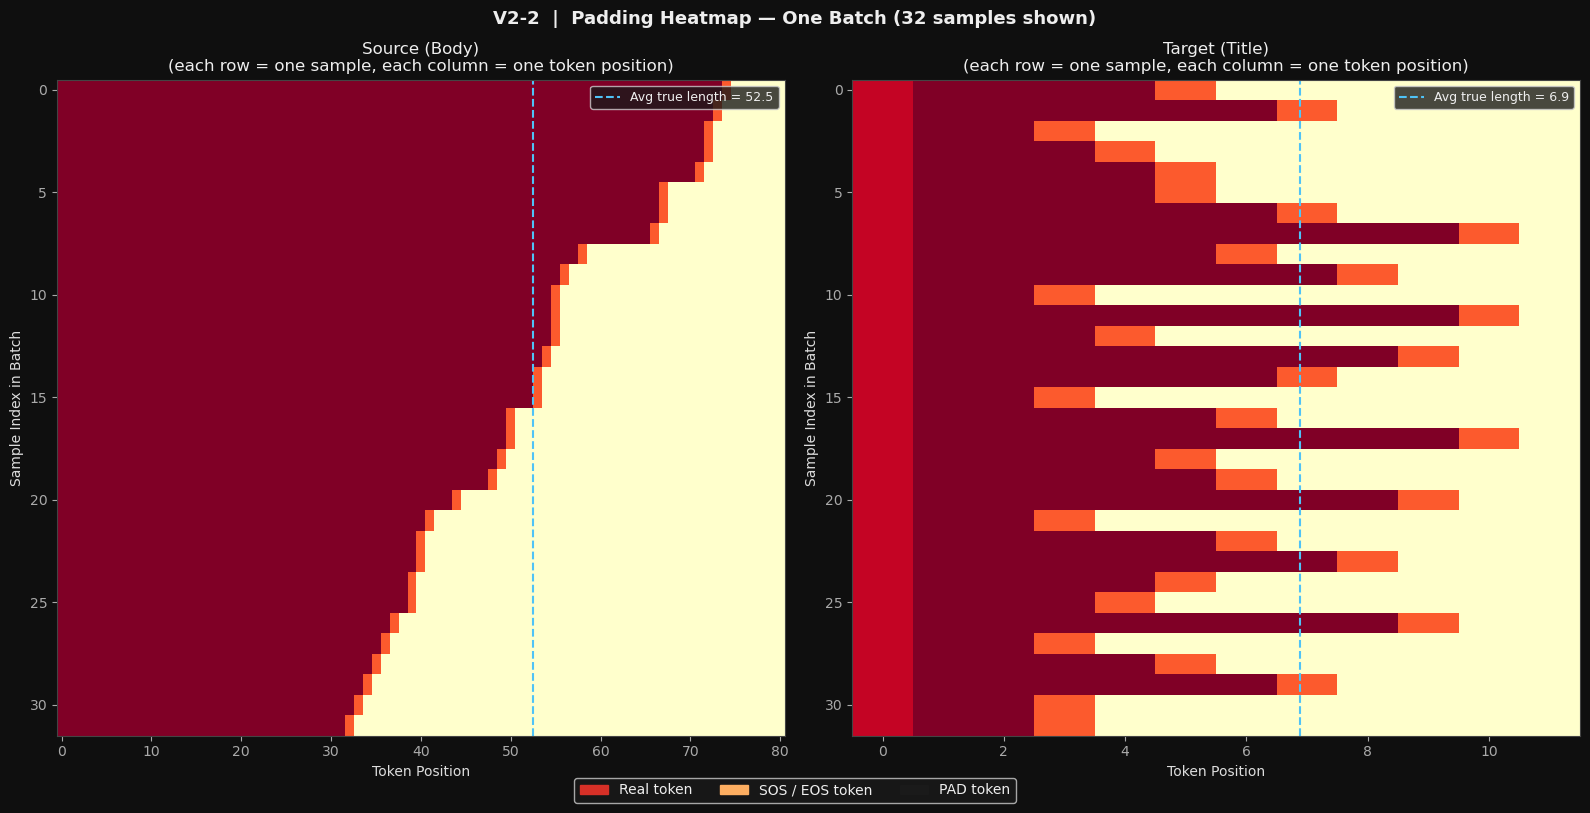

What to look for: Real tokens (warm colors) left side, PAD (dark) right side ✓


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("V2-2  |  Padding Heatmap — One Batch (32 samples shown)", fontsize=13, fontweight="bold")

src_b, tgt_b, sl_b, tl_b = next(iter(train_loader))

# Show first 32 samples for readability
n_show = 32

for ax, tensor, lens, title, max_len in [
    (axes[0], src_b[:n_show], sl_b[:n_show], "Source (Body)", MAX_SRC_LEN),
    (axes[1], tgt_b[:n_show], tl_b[:n_show], "Target (Title)", MAX_TGT_LEN),
]:
    data = tensor.numpy().astype(float)

    # Create a visibility mask:
    #   2 = real token
    #   1 = EOS token
    #   0 = PAD
    vis = np.zeros_like(data)
    for row_i, (row, true_len) in enumerate(zip(data, lens)):
        for col_j, val in enumerate(row):
            if val == vocab.PAD_IDX:
                vis[row_i, col_j] = 0.0   # PAD — dark
            elif val == vocab.EOS_IDX:
                vis[row_i, col_j] = 0.6   # EOS — mid
            elif val == vocab.SOS_IDX:
                vis[row_i, col_j] = 0.85  # SOS — bright
            else:
                vis[row_i, col_j] = 1.0   # real word — full bright

    ax.imshow(vis, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1,
              interpolation="nearest")
    ax.set_title(f"{title}\n(each row = one sample, each column = one token position)")
    ax.set_xlabel("Token Position")
    ax.set_ylabel("Sample Index in Batch")

    # Mark the average true length
    avg_len = lens.float().mean().item()
    ax.axvline(avg_len, color="#4fc3f7", linestyle="--", linewidth=1.5,
               label=f"Avg true length = {avg_len:.1f}")
    ax.legend(fontsize=9, loc="upper right")

# Legend patches
legend_patches = [
    mpatches.Patch(color="#d73027", label="Real token"),
    mpatches.Patch(color="#fdae61", label="SOS / EOS token"),
    mpatches.Patch(color="#1a1a1a", label="PAD token"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("v2_2_padding_heatmap.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("What to look for: Real tokens (warm colors) left side, PAD (dark) right side ✓")

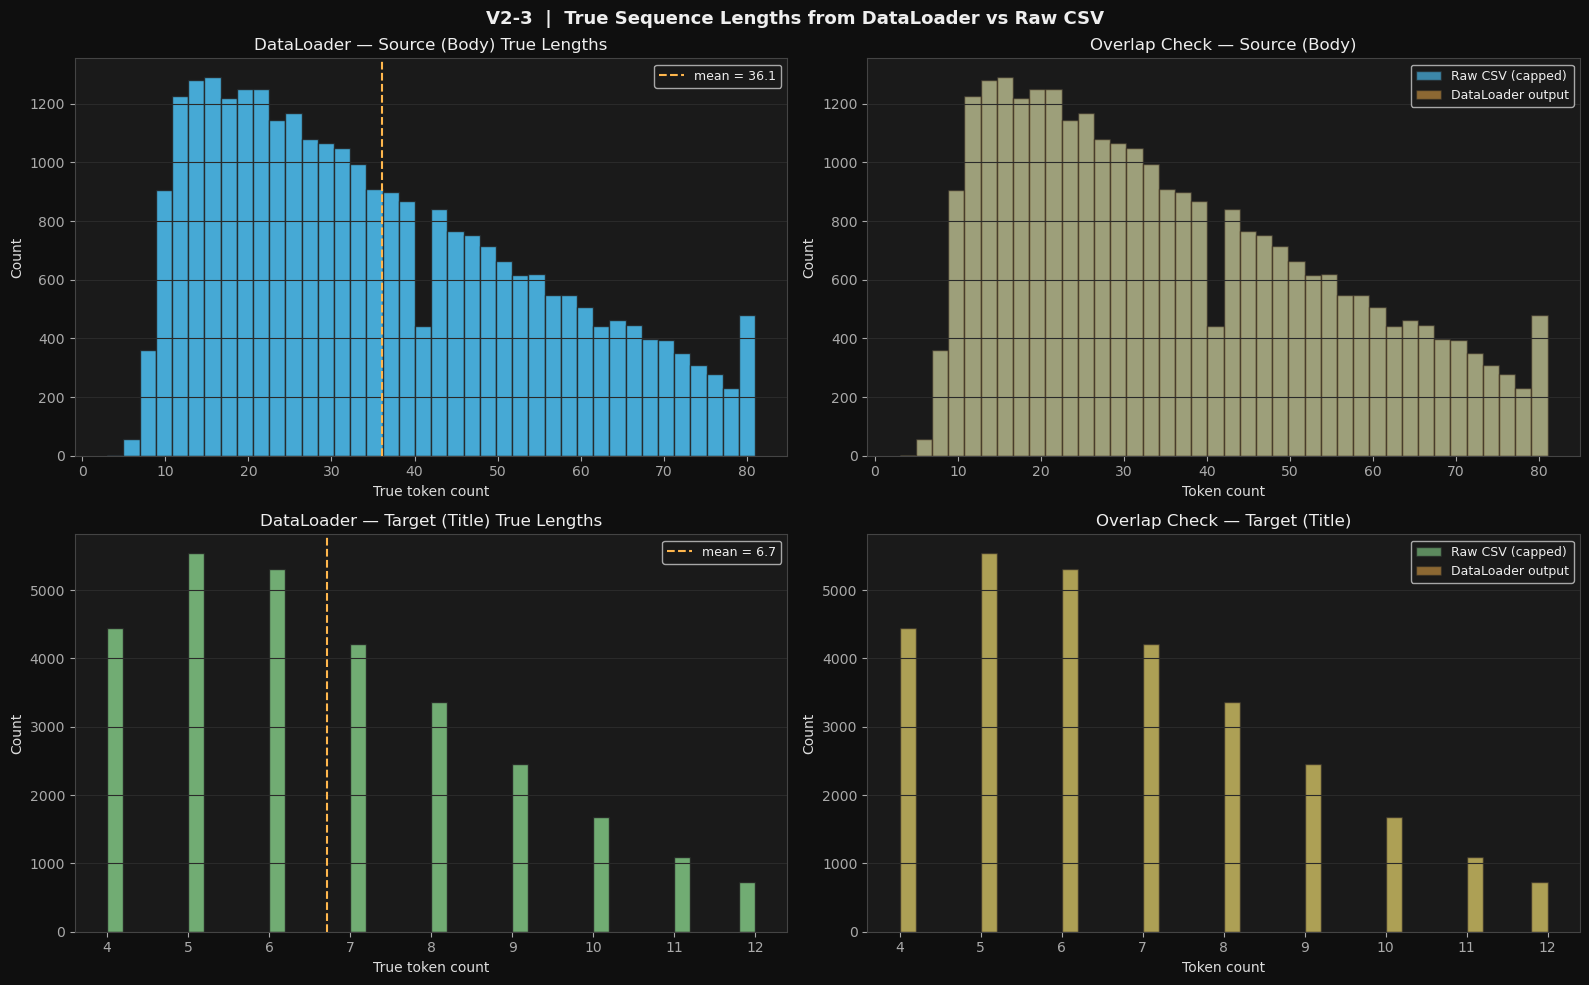

  Mean src_len from DataLoader : 36.1
  Mean tgt_len from DataLoader : 6.7
  If the two bars overlap well in the right plots → encoding is correct ✓


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("V2-3  |  True Sequence Lengths from DataLoader vs Raw CSV", fontsize=13, fontweight="bold")

# Collect all true lengths from the DataLoader (full pass)
print("Collecting lengths from train loader (one full pass)...")
all_src_lens, all_tgt_lens = [], []
for src, tgt, sl, tl in train_loader:
    all_src_lens.extend(sl.tolist())
    all_tgt_lens.extend(tl.tolist())

# Also compute raw lengths from CSV for comparison
raw_src_lens = train_df["body_final"].dropna().apply(lambda x: len(str(x).split()) + 1)  # +1 for EOS
raw_tgt_lens = train_df["title_final"].dropna().apply(lambda x: len(str(x).split()) + 2)  # +2 for SOS+EOS

for row, (dl_lens, raw_lens, label) in enumerate([
    (all_src_lens, raw_src_lens, "Source (Body)"),
    (all_tgt_lens, raw_tgt_lens, "Target (Title)"),
]):
    # Left: DataLoader distribution
    ax = axes[row][0]
    ax.hist(dl_lens, bins=40, color=ACCENT[row], edgecolor="#222", alpha=0.85)
    ax.axvline(np.mean(dl_lens), color="#ffb74d", linestyle="--", linewidth=1.5,
               label=f"mean = {np.mean(dl_lens):.1f}")
    ax.set_title(f"DataLoader — {label} True Lengths")
    ax.set_xlabel("True token count")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y")

    # Right: CSV raw lengths (should match DataLoader up to cap)
    ax = axes[row][1]
    capped = raw_lens.clip(upper=MAX_SRC_LEN if row == 0 else MAX_TGT_LEN)
    ax.hist(capped, bins=40, color=ACCENT[row], edgecolor="#222", alpha=0.65, label="Raw CSV (capped)")
    ax.hist(dl_lens, bins=40, color=ACCENT[2], edgecolor="#222", alpha=0.5,  label="DataLoader output")
    ax.set_title(f"Overlap Check — {label}")
    ax.set_xlabel("Token count")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("v2_3_length_distributions.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print(f"  Mean src_len from DataLoader : {np.mean(all_src_lens):.1f}")
print(f"  Mean tgt_len from DataLoader : {np.mean(all_tgt_lens):.1f}")
print(f"  If the two bars overlap well in the right plots → encoding is correct ✓")

In [27]:
print("\n── V2-4: Special Token Position Checks ─────────────────")

sos_first_ok = 0
eos_at_end_ok = 0
pad_after_eos_ok = 0
src_pad_position_ok = 0
total_checked = 0

for src, tgt, sl, tl in train_loader:
    for i in range(src.shape[0]):
        total_checked += 1
        src_row = src[i].tolist()
        tgt_row = tgt[i].tolist()
        s_len   = sl[i].item()
        t_len   = tl[i].item()

        # Check 1: SOS is first token in tgt
        if tgt_row[0] == vocab.SOS_IDX:
            sos_first_ok += 1

        # Check 2: EOS is at position t_len-1 in tgt
        if tgt_row[t_len - 1] == vocab.EOS_IDX:
            eos_at_end_ok += 1

        # Check 3: Everything after EOS in tgt is PAD
        if all(x == vocab.PAD_IDX for x in tgt_row[t_len:]):
            pad_after_eos_ok += 1

        # Check 4: Everything after s_len in src is PAD
        if all(x == vocab.PAD_IDX for x in src_row[s_len:]):
            src_pad_position_ok += 1

    break  # One batch is enough for this check

pct = lambda n: f"{n}/{total_checked} ({n/total_checked*100:.1f}%)"
print(f"  SOS is always tgt[0]          : {pct(sos_first_ok)}")
print(f"  EOS is at tgt[true_len - 1]   : {pct(eos_at_end_ok)}")
print(f"  All tokens after EOS are PAD  : {pct(pad_after_eos_ok)}")
print(f"  All tokens after src_len PAD  : {pct(src_pad_position_ok)}")

all_ok = (sos_first_ok == eos_at_end_ok == pad_after_eos_ok == src_pad_position_ok == total_checked)
print(f"\n  {'✅ All special token positions are correct' if all_ok else '⚠️  Some positions are wrong — check encode() calls'}")


── V2-4: Special Token Position Checks ─────────────────
  SOS is always tgt[0]          : 64/64 (100.0%)
  EOS is at tgt[true_len - 1]   : 64/64 (100.0%)
  All tokens after EOS are PAD  : 64/64 (100.0%)
  All tokens after src_len PAD  : 64/64 (100.0%)

  ✅ All special token positions are correct



── V2-5: Batch Sort Order Check (src_lens descending) ───
  Batches checked : 20
  Sort errors     : 0
  ✅ All batches correctly sorted descending by src_len


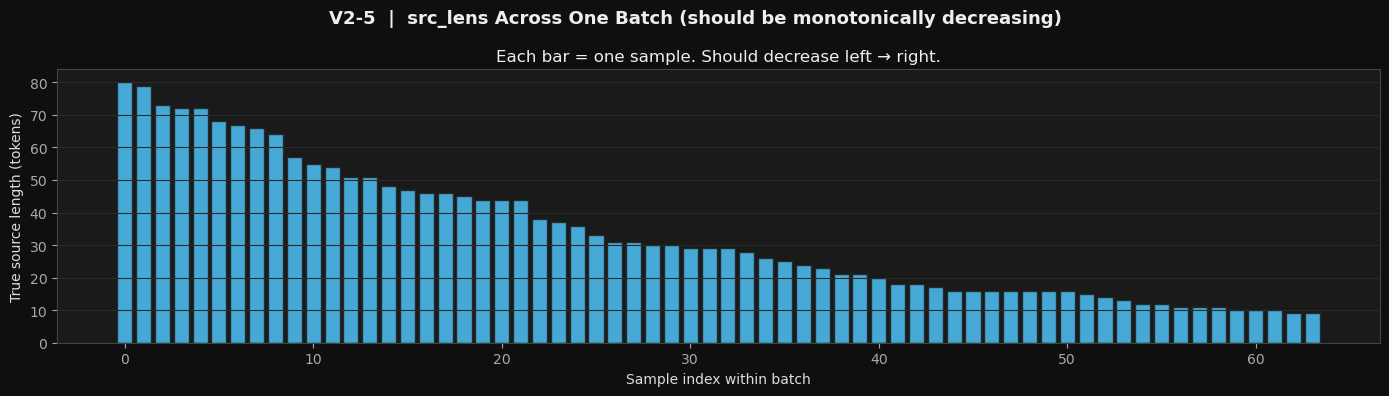

In [29]:
print("\n── V2-5: Batch Sort Order Check (src_lens descending) ───")

sort_errors = 0
batches_checked = 0

for src, tgt, sl, tl in train_loader:
    # Check that src_lens is monotonically non-increasing
    diffs = sl[1:] - sl[:-1]  # should all be <= 0
    if (diffs > 0).any():
        sort_errors += 1
    batches_checked += 1
    if batches_checked == 20:
        break

print(f"  Batches checked : {batches_checked}")
print(f"  Sort errors     : {sort_errors}")
print(f"  {'✅ All batches correctly sorted descending by src_len' if sort_errors == 0 else '⚠️  Sort order broken in collate_fn'}")

# Show one batch's sort pattern visually
src, tgt, sl, tl = next(iter(train_loader))

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("V2-5  |  src_lens Across One Batch (should be monotonically decreasing)", fontsize=13, fontweight="bold")
ax.bar(range(len(sl)), sl.tolist(), color=ACCENT[0], edgecolor="#222", alpha=0.85)
ax.set_xlabel("Sample index within batch")
ax.set_ylabel("True source length (tokens)")
ax.set_title("Each bar = one sample. Should decrease left → right.")
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig("v2_5_sort_order.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

In [31]:
print("\n── V2-6: Token Index Range Check ────────────────────────")
min_idx, max_idx = float('inf'), float('-inf')
out_of_range = 0

for src, tgt, sl, tl in train_loader:
    batch_min = min(src.min().item(), tgt.min().item())
    batch_max = max(src.max().item(), tgt.max().item())
    if batch_min < 0 or batch_max >= vocab.vocab_size:
        out_of_range += 1
    min_idx = min(min_idx, batch_min)
    max_idx = max(max_idx, batch_max)

print(f"  Minimum token index seen : {min_idx}  (must be >= 0)")
print(f"  Maximum token index seen : {max_idx}  (must be < {vocab.vocab_size})")
print(f"  Out-of-range batches     : {out_of_range}")
range_ok = (min_idx >= 0 and max_idx < vocab.vocab_size and out_of_range == 0)
print(f"  {'✅ All token indices are valid for the embedding layer' if range_ok else '⚠️  Out-of-range indices found — embedding will crash'}")


── V2-6: Token Index Range Check ────────────────────────
  Minimum token index seen : 0  (must be >= 0)
  Maximum token index seen : 33378  (must be < 33379)
  Out-of-range batches     : 0
  ✅ All token indices are valid for the embedding layer


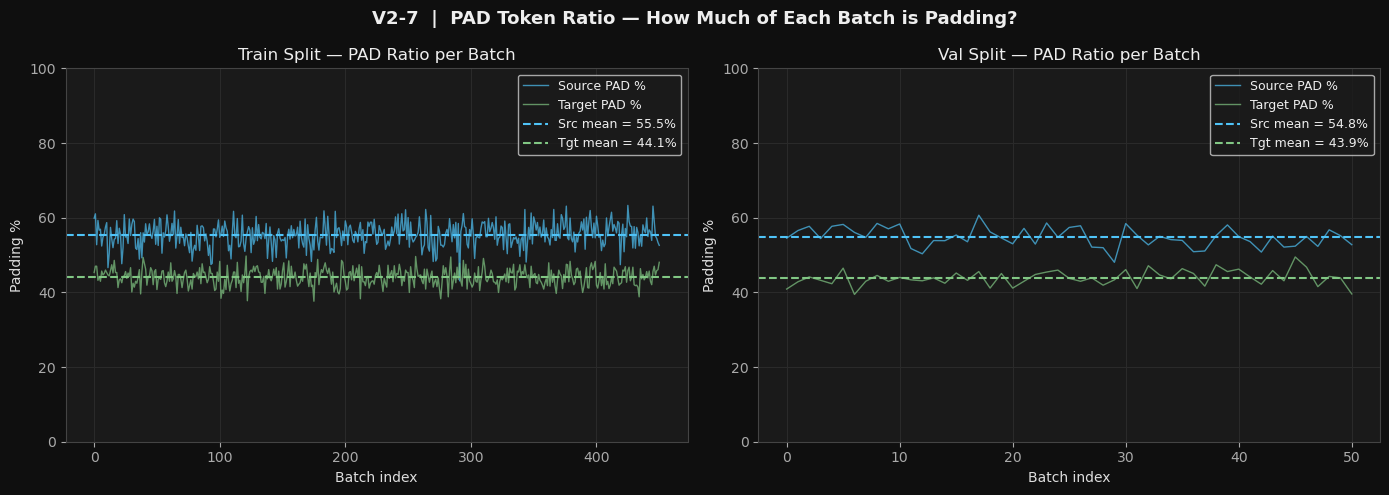


  Avg src PAD ratio (train): 54.8%
  Avg tgt PAD ratio (train): 43.9%

  Note: Target PAD ratio will be high because most titles are 4-5
  words but MAX_TGT_LEN=12. This is expected and handled by the
  loss masking in Step 7 — PAD positions do NOT affect training.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("V2-7  |  PAD Token Ratio — How Much of Each Batch is Padding?", fontsize=13, fontweight="bold")

for ax, loader, split_name, color in [
    (axes[0], train_loader, "Train", ACCENT[0]),
    (axes[1], val_loader,   "Val",   ACCENT[1]),
]:
    src_pad_ratios, tgt_pad_ratios = [], []
    for src, tgt, sl, tl in loader:
        src_pad = (src == vocab.PAD_IDX).float().mean().item()
        tgt_pad = (tgt == vocab.PAD_IDX).float().mean().item()
        src_pad_ratios.append(src_pad * 100)
        tgt_pad_ratios.append(tgt_pad * 100)

    ax.plot(src_pad_ratios, color=ACCENT[0], linewidth=1, alpha=0.7, label="Source PAD %")
    ax.plot(tgt_pad_ratios, color=ACCENT[1], linewidth=1, alpha=0.7, label="Target PAD %")
    ax.axhline(np.mean(src_pad_ratios), color=ACCENT[0], linestyle="--", linewidth=1.5,
               label=f"Src mean = {np.mean(src_pad_ratios):.1f}%")
    ax.axhline(np.mean(tgt_pad_ratios), color=ACCENT[1], linestyle="--", linewidth=1.5,
               label=f"Tgt mean = {np.mean(tgt_pad_ratios):.1f}%")
    ax.set_title(f"{split_name} Split — PAD Ratio per Batch")
    ax.set_xlabel("Batch index")
    ax.set_ylabel("Padding %")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 100)
    ax.grid(True)

plt.tight_layout()
plt.savefig("v2_7_pad_ratio.png", dpi=140, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

print(f"\n  Avg src PAD ratio (train): {np.mean(src_pad_ratios):.1f}%")
print(f"  Avg tgt PAD ratio (train): {np.mean(tgt_pad_ratios):.1f}%")
print(f"\n  Note: Target PAD ratio will be high because most titles are 4-5")
print(f"  words but MAX_TGT_LEN=12. This is expected and handled by the")
print(f"  loss masking in Step 7 — PAD positions do NOT affect training.")

In [35]:
print("\n── V2-8: Human-Readable Decode Check (5 random samples) ─")

src_b, tgt_b, sl_b, tl_b = next(iter(train_loader))
indices = torch.randperm(BATCH_SIZE)[:5]

print(f"{'─'*70}")
for rank, idx in enumerate(indices):
    decoded_src = vocab.decode(src_b[idx].tolist(), skip_special=True)
    decoded_tgt = vocab.decode(tgt_b[idx].tolist(), skip_special=True)
    print(f"Sample {rank+1}:")
    print(f"  Body  : {decoded_src[:100]}{'...' if len(decoded_src) > 100 else ''}")
    print(f"  Title : {decoded_tgt}")
    print(f"  Lengths → src: {sl_b[idx].item()} tokens | tgt: {tl_b[idx].item()} tokens")
    print(f"{'─'*70}")

print("\n✅  All Step 2 verifications complete.")
print("   The Dataset and DataLoader are working correctly.")
print("   Values to carry into Step 3:")
print(f"     vocab.vocab_size = {vocab.vocab_size}")
print(f"     MAX_SRC_LEN      = {MAX_SRC_LEN}")
print(f"     MAX_TGT_LEN      = {MAX_TGT_LEN}")
print(f"     BATCH_SIZE       = {BATCH_SIZE}")
print(f"     vocab.PAD_IDX    = {vocab.PAD_IDX}")
print(f"\n   → Next: Step 3 — Encoder (RNN)")


── V2-8: Human-Readable Decode Check (5 random samples) ─
──────────────────────────────────────────────────────────────────────
Sample 1:
  Body  : book going time spent courtroom basic questions crime <UNK> left <UNK> 200 pages realized book wasnt...
  Title : never gets going
  Lengths → src: 60 tokens | tgt: 5 tokens
──────────────────────────────────────────────────────────────────────
Sample 2:
  Body  : having read tremendously enjoyed club dumas flanders panel reverte looked forward <UNK> intellectual...
  Title : a lack of communion
  Lengths → src: 43 tokens | tgt: 6 tokens
──────────────────────────────────────────────────────────────────────
Sample 3:
  Body  : nice versions bible translation gives different perspective <UNK> prefer esv <UNK> noticed described...
  Title : great bible but theres a less <UNK> version
  Lengths → src: 34 tokens | tgt: 10 tokens
──────────────────────────────────────────────────────────────────────
Sample 4:
  Body  : book tells fascinating r